In [19]:
# Import Library
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Load MNIST data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [21]:
# Normalize and Reshape
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

In [22]:
# Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(x_train)

In [23]:
# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
# Compile and train model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Split training data into training and validation sets
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42) # Split 10% for validation

# Train the model using the training set and validation set
history = model.fit(datagen.flow(x_train, y_train, batch_size=64), epochs=10, validation_data=(x_val, y_val))

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


844/844 ━━━━━━━━━━━━━━━━━━━━ 70s 79ms/step - accuracy: 0.5925 - loss: 1.1146 - val_accuracy: 0.7965 - val_loss: 0.5138
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 65s 76ms/step - accuracy: 0.7512 - loss: 0.6607 - val_accuracy: 0.8277 - val_loss: 0.4490
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 62s 74ms/step - accuracy: 0.7796 - loss: 0.5884 - val_accuracy: 0.8408 - val_loss: 0.4059
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 61s 73ms/step - accuracy: 0.8005 - loss: 0.5351 - val_accuracy: 0.8520 - val_loss: 0.3922
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 75ms/step - accuracy: 0.8093 - loss: 0.5157 - val_accuracy: 0.8585 - val_loss: 0.3636
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 62s 73ms/step - accuracy: 0.8187 - loss: 0.4901 - val_accuracy: 0.8702 - val_loss: 0.3407
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 62s 73ms/step - accuracy: 0.8217 - loss: 0.4813 - val_accuracy: 0.8715 - val_loss: 0.3318
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 62s 73ms/step - accuracy: 0.8291 - loss: 0.4604 - val_accurac

In [26]:
# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8861 - loss: 0.3197
Test accuracy: 0.881600022315979


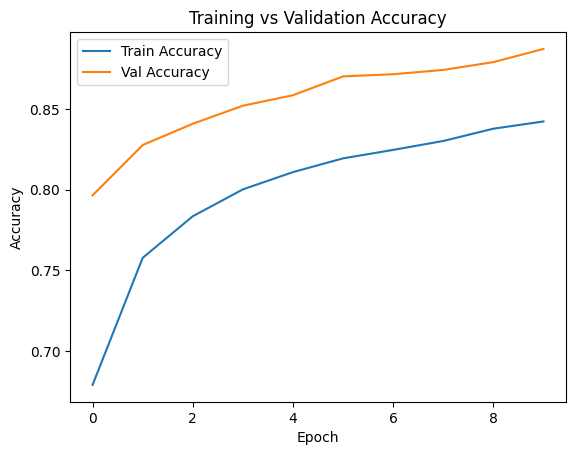

In [27]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

In [28]:
# Predict 5 samples
predictions = model.predict(x_test[:5])
predicted_classes = np.argmax(predictions, axis=1)

print("Predicted:", predicted_classes)
print("Actual:   ", y_test[:5].flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Predicted: [9 2 1 1 6]
Actual:    [9 2 1 1 6]
